 **LAB EXPERIMENT 5 \
 Classification using K-Nearest Neighbors (KNN) and
Decision Tree**

NAME: Priya Dharshini R\
ROLL NO.: 24BAD092

**SCENARIO 1 – K-NEAREST NEIGHBORS (KNN)**

**Problem Statement**\
Predict whether a tumor is benign or malignant based on medical measurements.

Breast Cancer Dataset Dataset Link:\
 https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset

**Target Variable:**

Diagnosis (Benign / Malignant)

**Input Feature:**\
• Radius\
• Texture\
• Perimeter\
• Area\
• Smoothness

**IN-LAB TASKS** (KNN Classification)

1.	Import required Python libraries.
2.	Load the Breast Cancer dataset.
3.	Perform data inspection & preprocessing.
4.	Encode target labels.
5.	Apply feature scaling (very important for KNN).
6.	Split dataset into training and testing sets.
7.	Train a KNN classifier.
8.	Experiment with different values of K.
9.	Predict diagnosis labels.
10.	Evaluate performance using:\
• Accuracy\
• Precision / Recall / F1 Score
11.	Identify misclassified cases.
12.	Analyze model sensitivity to K.

**Visualization**\
• Confusion Matrix\
• Accuracy vs K Plot\
• Decision Boundary (using two features)

Name : Priya Dharshini R
Register Number : 24BAD092
Scenario 1 - KNN Breast Cancer Classification

First Five Rows
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030       

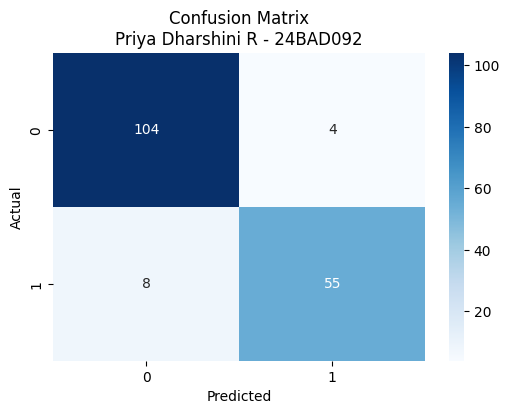

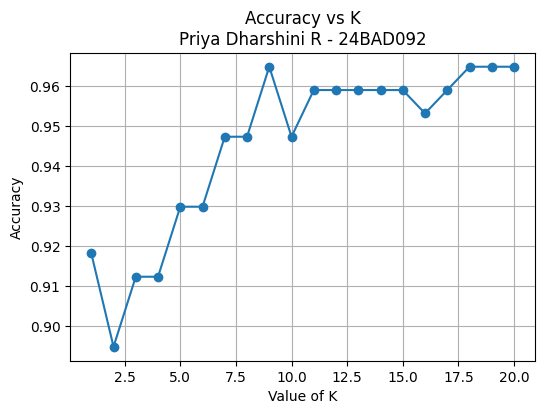


Misclassified Indexes
(array([  7,  20,  25,  39,  52,  71,  77,  82,  91, 135, 150, 164]),)


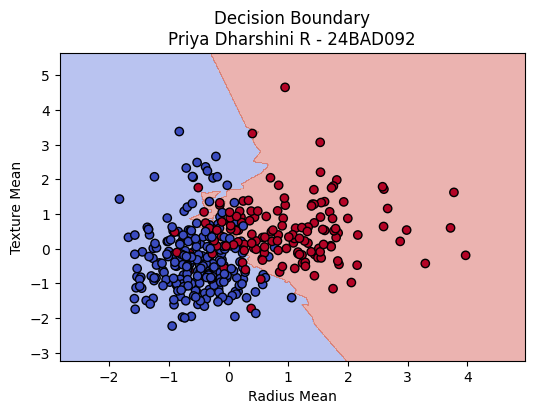

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Print Student Details
print("Name : Priya Dharshini R")
print("Register Number : 24BAD092")
print("Scenario 1 - KNN Breast Cancer Classification")

# Load Dataset
data = pd.read_csv(r"/content/sample_data/breast-cancer.csv")

# Data Inspection
print("\nFirst Five Rows")
print(data.head())

print("\nMissing Values")
print(data.isnull().sum())

# Select Features
X = data[['radius_mean',
          'texture_mean',
          'perimeter_mean',
          'area_mean',
          'smoothness_mean']]

y = data['diagnosis']

# Encode Labels
le = LabelEncoder()
y = le.fit_transform(y)

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)
# Train Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
# Prediction
y_pred = knn.predict(X_test)

# Evaluation
print("\nAccuracy")
print(accuracy_score(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Confusion Matrix (Graph 1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix\nPriya Dharshini R - 24BAD092")
plt.show()

# Accuracy vs K (Graph 2)
k_values = range(1,21)
accuracy_list = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracy_list.append(acc)


plt.figure(figsize=(6,4))
plt.plot(k_values,
         accuracy_list,
         marker='o')

plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K\nPriya Dharshini R - 24BAD092")
plt.grid()
plt.show()

# Misclassified Cases
mis = np.where(y_test != y_pred)

print("\nMisclassified Indexes")
print(mis)

# Decision Boundary (Graph 3 - Colored)
X2 = data[['radius_mean','texture_mean']]
y2 = le.fit_transform(data['diagnosis'])

X2_scaled = scaler.fit_transform(X2)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled,
    y2,
    test_size=0.3,
    random_state=42
)

model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(X_train2, y_train2)

x_min, x_max = X_train2[:,0].min()-1, X_train2[:,0].max()+1
y_min, y_max = X_train2[:,1].min()-1, X_train2[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min,x_max,0.01),
    np.arange(y_min,y_max,0.01)
)

Z = model2.predict(
    np.c_[xx.ravel(),yy.ravel()]
)

Z = Z.reshape(xx.shape)
plt.figure(figsize=(6,4))

# Colored background
plt.contourf(xx,
             yy,
             Z,
             cmap='coolwarm',
             alpha=0.4)

# Colored points
plt.scatter(
    X_train2[:,0],
    X_train2[:,1],
    c=y_train2,
    cmap='coolwarm',
    edgecolor='black'
)
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title("Decision Boundary\nPriya Dharshini R - 24BAD092")
plt.show()



**CODE EXPLANATION**


**Step 1 – Import Libraries**

The required Python libraries are imported for data analysis and machine learning.

NumPy and Pandas are used for handling data.
Matplotlib and Seaborn are used for plotting graphs.

Scikit-learn is used to implement the KNN algorithm.


**Step 2 – Load Dataset**

The Breast Cancer dataset is loaded using Pandas.

The dataset contains tumor measurements such as radius, texture, perimeter, area, and smoothness.

The target variable is Diagnosis which indicates whether the tumor is benign or malignant.

 **Step 3 – Data Inspection**

The dataset is inspected by displaying the first five rows and checking for missing values.

This helps in understanding the dataset structure.

 **Step 4 – Feature Selection**

The selected input features are:

• Radius Mean\
• Texture Mean\
• Perimeter Mean\
• Area Mean\
• Smoothness Mean

The target variable is Diagnosis.

 **Step 5 – Label Encoding**

The diagnosis values are converted into numerical form.

Benign is converted to 0.\
Malignant is converted to 1.

Machine learning models require numerical data.

 **Step 6 – Feature Scaling**

Feature scaling is applied because KNN uses distance calculations.

StandardScaler is used to normalize the data.

This improves the performance of the model.

**Step 7 – Train Test Split**

The dataset is divided into training data and testing data.

70% of the data is used for training.

30% of the data is used for testing.

 **Step 8 – Train KNN Model**

The KNN classifier is trained using the training data.

The value of K is selected as 5.

The model learns patterns from the training data.

 **Step 9 – Prediction**

The trained model predicts whether the tumor is benign or malignant.

 **Step 10 – Model Evaluation**

The model performance is evaluated using:

• Accuracy\
• Precision\
• Recall\
• F1 Score

These metrics show how well the model performs.

**Step 11 – Confusion Matrix**

The confusion matrix is plotted to show correct and incorrect predictions.

This helps to understand model performance visually.

**Step 12 – Accuracy vs K Graph**

Different values of K are tested from 1 to 20.

Accuracy is calculated for each value.

A graph is plotted to find the best value of K.

 **Step 13 – Misclassified Cases**

The misclassified cases are identified.

These are the cases where the model predicted incorrectly.

**Step 14 – Decision Boundary**

A decision boundary is plotted using radius and texture features.

This graph shows how the KNN algorithm separates benign and malignant tumors.

 **Conclusion**

The KNN algorithm successfully classified tumors as benign and malignant with good accuracy.


-------------

**SCENARIO 2 – DECISION TREE CLASSIFIER**

**Problem Statement**\
Predict whether a loan application should be approved or rejected.

Loan Prediction Dataset
Dataset Link:\
 https://www.kaggle.com/datasets/ninzaami/loan-predication

**Target Variable:** \
 Loan Status (Approved / Rejected)

**Input Features**\
• Applicant Income\
• Loan Amount\
• Credit History\
• Education\
• Property Area

**IN-LAB TASKS** (Decision Tree Classification)

1.	Import required Python libraries.
2.	Load the Loan Prediction dataset.
3.	Perform preprocessing:
• Handle missing values
• Encode categorical variables
4.	Split dataset into training and testing sets.
5.	Train a Decision Tree classifier.
6.	Experiment with tree depth / pruning.
7.	Predict loan status.
8.	Evaluate performance using:\
• Accuracy\
• Precision / Recall / F1 Score
9.	Analyze feature importance.
10.	Detect overfitting behavior.
11.	Compare shallow vs deep trees.

**Visualization**\
• Confusion Matrix\
• Tree Structure Plot\
• Feature Importance Plot

Name : Priya Dharshini R
Register Number : 24BAD092
Scenario 2 - Decision Tree Loan Prediction

First 5 Rows
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0  

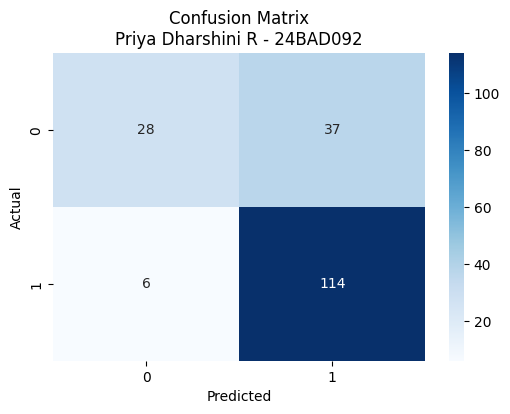

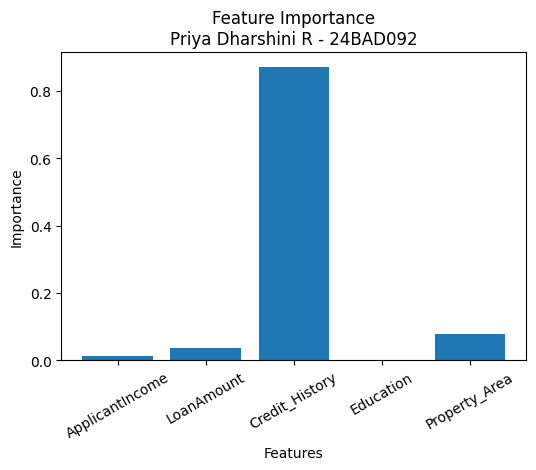

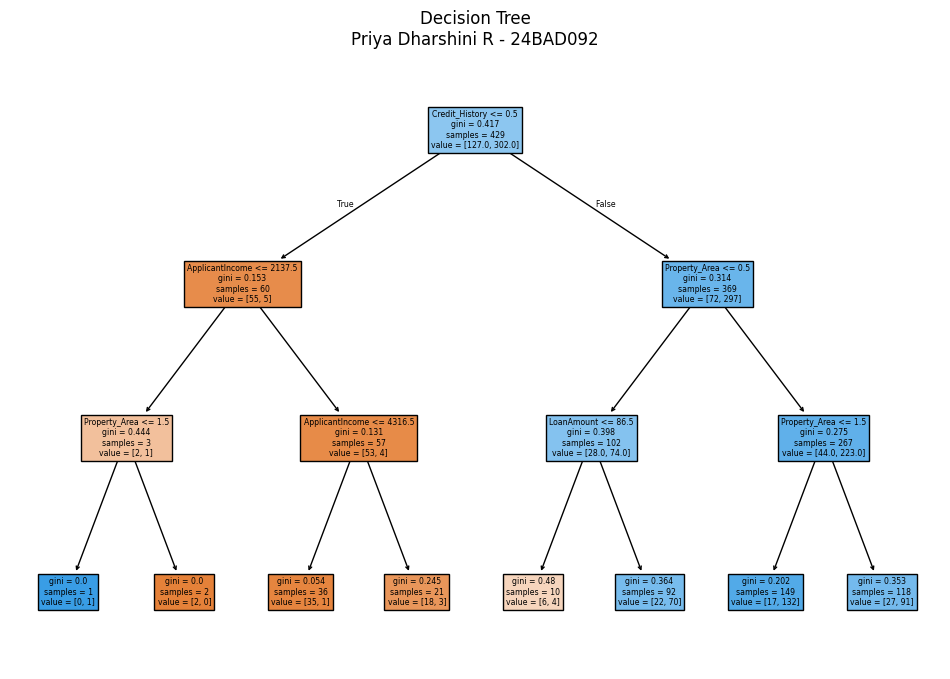


Training Accuracy: 0.8275058275058275
Testing Accuracy: 0.7675675675675676

Shallow Tree Accuracy
0.7837837837837838

Deep Tree Accuracy
0.6648648648648648

Program Completed Successfully


In [ ]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Print Student Details
print("Name : Priya Dharshini R")
print("Register Number : 24BAD092")
print("Scenario 2 - Decision Tree Loan Prediction")

# Load Dataset
data = pd.read_csv(r"/content/sample_data/train_u6lujuX_CVtuZ9i (1).csv")

# Data Inspection
print("\nFirst 5 Rows")
print(data.head())
print("\nMissing Values")
print(data.isnull().sum())

# Handle Missing Values
data['LoanAmount'] = data['LoanAmount'].fillna(
    data['LoanAmount'].mean()
)

data['Credit_History'] = data['Credit_History'].fillna(
    data['Credit_History'].mode()[0]
)

data['Education'] = data['Education'].fillna(
    data['Education'].mode()[0]
)

data['Property_Area'] = data['Property_Area'].fillna(
    data['Property_Area'].mode()[0]
)

data['ApplicantIncome'] = data['ApplicantIncome'].fillna(
    data['ApplicantIncome'].mean()
)
# Select Features
X = data[['ApplicantIncome',
          'LoanAmount',
          'Credit_History',
          'Education',
          'Property_Area']].copy()

y = data['Loan_Status']
# Encode Categorical Variables
le = LabelEncoder()
X.loc[:, 'Education'] = le.fit_transform(X['Education'])
X.loc[:, 'Property_Area'] = le.fit_transform(X['Property_Area'])
y = le.fit_transform(y)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)
# Train Decision Tree Model
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("\nAccuracy")
print(accuracy_score(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))


# Confusion Matrix (Visualization 1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix\nPriya Dharshini R - 24BAD092")
plt.show()

# Feature Importance (Visualization 2)
importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))
plt.bar(features, importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance\nPriya Dharshini R - 24BAD092")
plt.xticks(rotation=30)
plt.show()

# Tree Structure (Visualization 3)
plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=features,
    filled=True
)

plt.title("Decision Tree\nPriya Dharshini R - 24BAD092")
plt.show()

# Detect Overfitting (No Graph Required)
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("\nTraining Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

# Compare Shallow vs Deep Trees
shallow_tree = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

deep_tree = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

shallow_tree.fit(X_train, y_train)
deep_tree.fit(X_train, y_train)

print("\nShallow Tree Accuracy")
print(shallow_tree.score(X_test, y_test))
print("\nDeep Tree Accuracy")
print(deep_tree.score(X_test, y_test))
print("\nProgram Completed Successfully")

**CODE EXPLANATION**

**Step 1 – Import Libraries**

The required Python libraries are imported.

NumPy and Pandas are used for handling data.

Matplotlib and Seaborn are used for graphs.

Scikit-learn is used for implementing the Decision Tree algorithm.

**Step 2 – Load Dataset**

The Loan Prediction dataset is loaded using Pandas.

The dataset contains information about loan applicants.

The target variable is Loan Status which indicates whether the loan is approved or rejected.

**Step 3 – Data Inspection**

The dataset is inspected by displaying the first five rows and checking missing values.

This helps in understanding the dataset.

**Step 4 – Handle Missing Values**

Missing values are replaced using suitable methods.

Loan Amount is replaced with mean value.

Credit History is replaced with mode value.

Education is replaced with mode value.

Property Area is replaced with mode value.

Applicant Income is replaced with mean value.

This makes the dataset complete.

**Step 5 – Feature Selection**

The selected input features are:

Applicant Income\
Loan Amount\
Credit History\
Education\
Property Area

The target variable is Loan Status.

**Step 6 – Encode Categorical Variables**

Categorical values are converted into numerical values.

Education and Property Area are converted into numbers.

Loan Status is also converted into numerical values.

This allows the machine learning model to process the data.

**Step 7 – Train Test Split**

The dataset is divided into training and testing data.

70% data is used for training.\
30% data is used for testing.

Training data is used to train the model.\
Testing data is used to evaluate the model.

**Step 8 – Train Decision Tree Model**

The Decision Tree classifier is trained using the training data.

The maximum depth of the tree is set to 3.

The model learns patterns from the training data.

**Step 9 – Prediction**

The trained model predicts whether the loan is approved or rejected.

**Step 10 – Model Evaluation**

The model performance is evaluated using:

Accuracy\
Precision\
Recall\
F1 Score

These metrics show how well the model performs.

**Step 11 – Confusion Matrix**

The confusion matrix is plotted.

This graph shows correct and incorrect predictions.

**Step 12 – Feature Importance**

Feature importance is calculated.

This shows which features influence loan prediction the most.

A bar graph is plotted.

**Step 13 – Tree Structure Plot**

The Decision Tree structure is plotted.

This graph shows how the model makes decisions.

**Step 14 – Detect Overfitting**

Training accuracy and testing accuracy are compared.

This helps to detect overfitting.

**Step 15 – Compare Shallow and Deep Trees**

Two Decision Tree models are compared.

Shallow Tree with depth 2.\
Deep Tree with depth 10.

Accuracy is calculated for both models.

**Conclusion**

The Decision Tree model successfully predicted loan approval status and the performance of the model was analyzed.
